# Score Modeling Tutorial


## What you will learn

1. What is the score?
2. How to train a score model from scratch
3. How to use the score-model package to make this easy
3. How to train a conditional score model
4. How to solve inverse problems with a pre-trained score model

In [91]:
# !pip install --quiet score_models colorcet SciencePlots # For colab notebooks.
from score_models.plot_utils import *
from score_models.toy_distributions import *
import torch
from tqdm import tqdm

# The score

The score is a vector field **pushing particles towards regions of higher density**
$$\mathbf{s}(x) = \nabla_x \log p(x)\,. $$

## Why not model $p(\mathbf{x})$ instead?
The density must be normalized
$$
    \int_{\mathbb{R}^n} p(\mathbf{x}) \mathrm{d} \mathbf{x} = 1\, .
$$
This is a difficult constraint to satisfy in high-dimensional spaces ($n \gg 1$). 

## The score is local
Consider
$$
    p(\mathbf{x}) = \frac{1}{\mathcal{Z}}e^{-E(\mathbf{x})}
$$
where $\mathcal{Z}$ is the normalization and $E$ an energy function. Therefore
$$
    \nabla_{\mathbf{x}} \log p(\mathbf{x}) = - \nabla_{\mathbf{x}} E(\mathbf{x})\, .
$$

In [83]:
distribution = eggbox(4, mode_width=0.1, box_size=1)

from torch.func import grad, vmap
def logp(x):
    return distribution.log_prob(x)

def score(x):
    return vmap(grad(logp))(x)

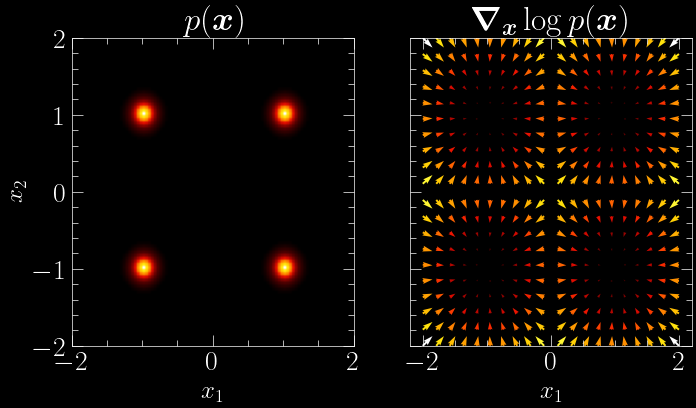

In [84]:
fig, axs = plt.subplots(1, 2, figsize=(8, 4), sharey=True)

ax = axs[0]
plot_density(logp, ax=ax)
ax.set_title(r"$p(\bm{x})$")
ax.set_ylabel(r"$x_2$")
ax.set_xlabel(r"$x_1$");

ax = axs[1]
plot_score(score, ax=ax)
ax.set_title(r"$\grad_{\bm{x}} \log p(\bm{x})$")
ax.set_xlabel(r"$x_1$");

In [85]:
distribution = eggbox(4, mode_width=0.1, box_size=1, weights=(1, 0.5, 0.5, 0.1))

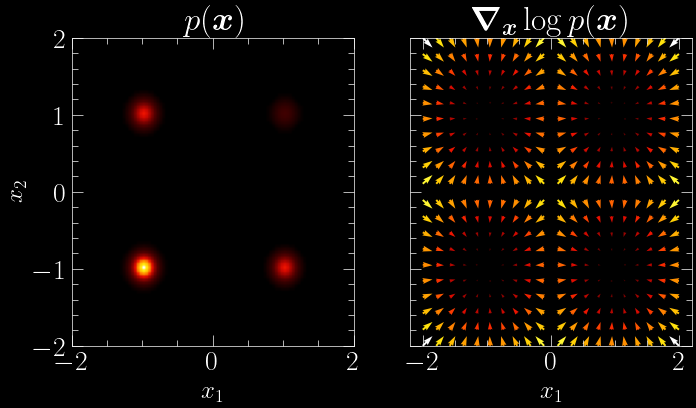

In [86]:
fig, axs = plt.subplots(1, 2, figsize=(8, 4), sharey=True)

ax = axs[0]
plot_density(logp, ax=ax)
ax.set_title(r"$p(\bm{x})$")
ax.set_ylabel(r"$x_2$")
ax.set_xlabel(r"$x_1$");

ax = axs[1]
plot_score(score, ax=ax)
ax.set_title(r"$\grad_{\bm{x}} \log p(\bm{x})$")
ax.set_xlabel(r"$x_1$");

# Score matching

To train a score-model, we aim to minimize
$$
    \mathcal{L}_\theta = \mathbb{E}_{p(\mathbf{x})} 
    \bigg[\big\lVert \mathbf{s}_\theta(\mathbf{x}) - \nabla_{\mathbf{x}} \log p(\mathbf{x}) \big\rVert^2_2 \bigg] \, .
$$

In [93]:
def loss(x, model):
    return (model(x) - score(x)).pow(2).sum(dim=-1).mean()

A score model has the same shape for its input and output 
$$
\mathbf{s}_\theta: \mathbb{R}^n \rightarrow \mathbb{R}^n\, .
$$

In [ ]:
# Score model architecture
from score_models import MLP

net = MLP(
    channels=2,       # Input and output dimensions
    width=128,        # Hidden layer width
    layers=2,         # Number of hidden layers
    attention=False,  # Whether to use self-attention
    activation="relu",
)

# Hack for this toy example: ignore time input
def model(x):
    t = torch.zeros(x.shape[0]) # Dummy time input
    return net(t, x)

100%|██████████| 2000/2000 [00:08<00:00, 244.15it/s]


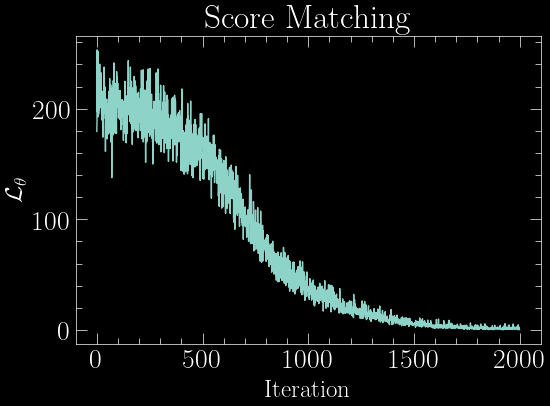

In [ ]:
# Basic training loop (as an example)
N = 2000 # Number of training samples
B = 128  # Batch size
opt = torch.optim.Adam(net.parameters(), lr=1e-4)
losses = []
for epoch in tqdm(range(N)):
    x = distribution.sample((B,))
    l = loss(x, model)
    losses.append(l.item())
    
    opt.zero_grad()
    l.backward()
    opt.step()

plt.figure(figsize=(6, 4))
plt.plot(losses)
plt.title("Score Matching")
plt.ylabel(r"$\mathcal{L}_\theta$")
plt.xlabel("Iteration");

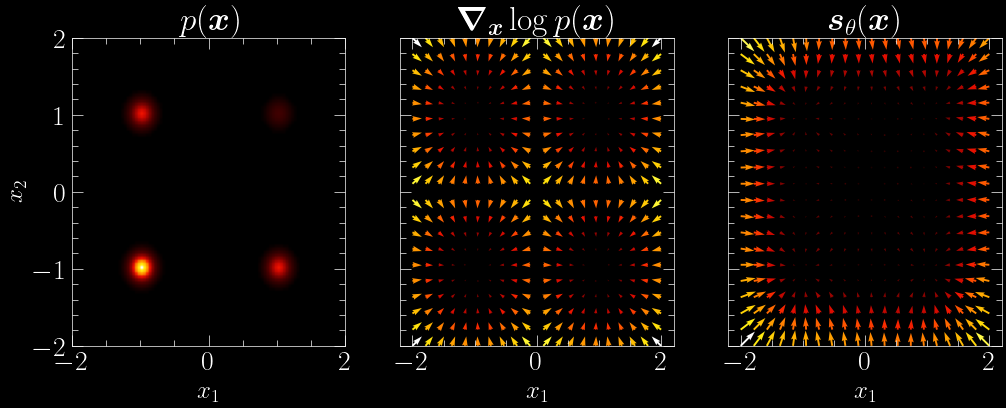

In [99]:
fig, axs = plt.subplots(1, 3, figsize=(12, 4), sharey=True)
extent = (-2, 2, -2, 2)

ax = axs[0]
plot_density(logp, ax=ax, extent=extent)
ax.set_title(r"$ p(\bm{x})$")
ax.set_ylabel(r"$x_2$")
ax.set_xlabel(r"$x_1$")

ax = axs[1]
plot_score(score, ax=ax, extent=extent)
ax.set_title(r"$\grad_{\bm{x}} \log p(\bm{x})$")
ax.set_xlabel(r"$x_1$")

ax = axs[2]
plot_score(model, ax=ax, extent=extent)
ax.set_title(r"$\bm{s}_\theta(\bm{x})$")
ax.set_xlabel(r"$x_1$");

# Denoising Score Matching

**Solution: perturb the samples to explore the space with some noise schedule**
$$
    \mathcal{L}^{\mathrm{DSM}}_\theta = \mathbb{E}_{p(t)}\mathbb{E}_{p(\mathbf{x}_t, \mathbf{x}_0)}
    \bigg[
        \big\lVert 
            \mathbf{s}_\theta(t, \mathbf{x}_t) - \nabla_{x_t} \log p(\mathbf{x}_t \mid \mathbf{x}_0)
        \big\rVert^2_2
    \bigg]\, .
$$

Define a noise schedule, e.g.
$$
    \sigma(t) \propto C^t
$$
for $t \in [0, 1]$.

In [109]:
# Noise schedule
from score_models import VESDE

sde = VESDE(sigma_min=0.01, sigma_max=2)
sigma = sde.sigma

Let $\mathbf{z}$ be some Gaussian noise and
$$
    \mathbf{x}_t = \mathbf{x}_0 + \sigma(t) \mathbf{z}
$$
Then the DSM loss can simplify to
$$
    \mathcal{L}_\theta^{\mathrm{DSM}} = 
    \mathbb{E}_{p(t)}\mathbb{E}_{p(\mathbf{z}, \mathbf{x}_0)}
    \bigg[
        \big\lVert 
            \boldsymbol{\epsilon}_\theta\big(t, \mathbf{x}_t\big) + \mathbf{z}
        \big\rVert^2_2
    \bigg]\, .
$$

In [ ]:
def dsm_loss(x, model):
    t = torch.rand(x.shape[0])          # Sample time uniformly from [0, 1]
    z = torch.randn_like(x)             # Sample Gaussian noise
    sigma_t = sigma(t).unsqueeze(-1)    # Get noise scale at time t
    x_t = x + sigma_t * z               # Perturb data with noise

    epsilon = model(t, x_t)
    loss = ((epsilon + z) ** 2).sum(dim=-1).mean()
    return loss

We redefine the score model for training stability
$$
    \mathbf{s}_\theta(t, \mathbf{x}_t) = \frac{\epsilon_\theta(t, \mathbf{x}_t)}{\sigma(t)}
$$

In [ ]:
epsilon = MLP(
    channels=2,       # Input and output dimensions
    width=128,        # Hidden layer width
    layers=4,         # Number of hidden layers
    attention=False,  # Whether to use self-attention
    activation="relu",
)

def model(t, x):
    return epsilon(t, x) / sigma(t).unsqueeze(-1)

100%|██████████| 10000/10000 [00:46<00:00, 214.10it/s]


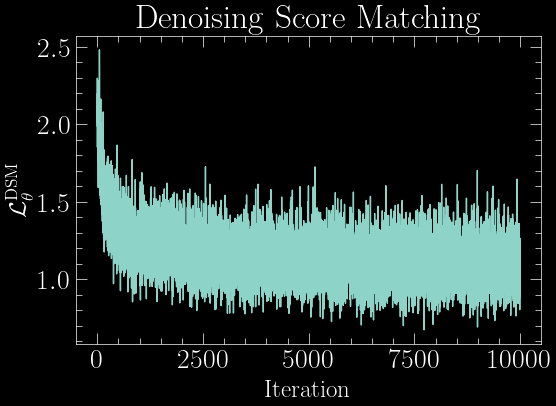

In [122]:
# Basic training loop (as an example)
N = 10000 # Number of training samples
B = 128  # Batch size
opt = torch.optim.Adam(epsilon.parameters(), lr=1e-4)
losses = []
for epoch in tqdm(range(N)):
    x = distribution.sample((B,))
    l = dsm_loss(x, epsilon) # Swapped to DSM loss
    losses.append(l.item())
    
    opt.zero_grad()
    l.backward()
    opt.step()

plt.figure(figsize=(6, 4))
plt.plot(losses)
plt.title("Denoising Score Matching")
plt.ylabel(r"$\mathcal{L}_\theta^{\mathrm{DSM}}$")
plt.xlabel("Iteration");

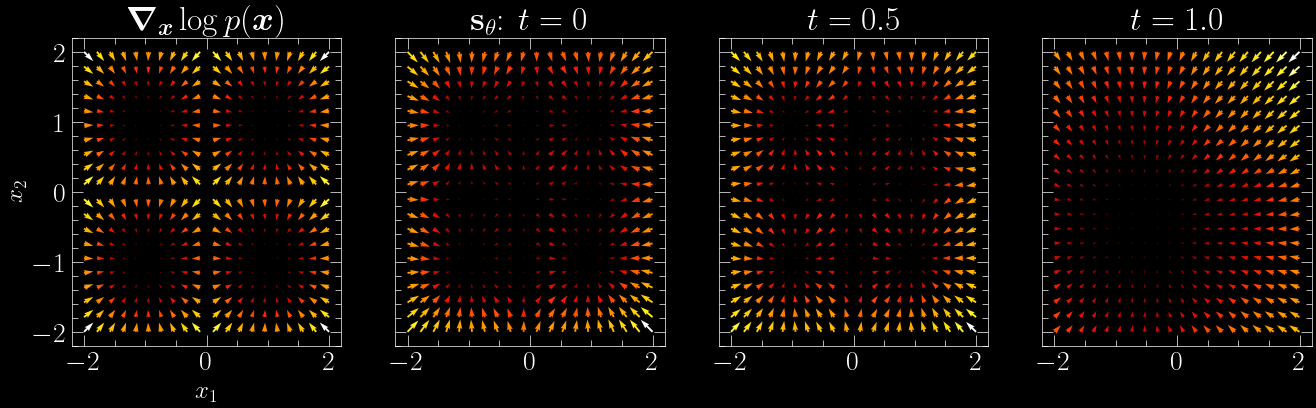

In [128]:
fig, axs = plt.subplots(1, 4, figsize=(16, 4), sharey=True)

ax = axs[0]
plot_score(score, ax=ax, extent=extent)
ax.set_title(r"$\grad_{\bm{x}} \log p(\bm{x})$")
ax.set_xlabel(r"$x_1$")
ax.set_ylabel(r"$x_2$")

for i, t in enumerate([0, 0.5, 1.]):
    ax = axs[i+1]
    plot_score(lambda x: model(torch.tensor([t]*x.shape[0]), x), ax=ax, extent=extent)
    if i == 0:
        ax.set_title(r"$\mathbf{s}_\theta$: "+ r"$t={}$".format(t))
    else:
        ax.set_title(r"$t={}$".format(t))

# Using the score-model package

## Create a dataset

In [ ]:
from torchvision.datasets import MNIST
from torchvision.transforms import ToTensor

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")


path = "../../../data"
mnist = MNIST(path, download=True)

class Dataset(torch.utils.data.Dataset):
    def __init__(self, mnist, unconditional_frequency=0.25):
        self.mnist = mnist
        self.p = unconditional_frequency
    
    def __len__(self):
        return len(self.mnist)
    
    def __getitem__(self, idx):
        """Logic to load a image (and possibly labels) from the disk to the GPU memory."""
        x, _ = self.mnist[idx]
        return x


dataset = Dataset(mnist)

## Create the model

In [ ]:
# Hyperparameters
channels = 1                    # Number of color channels for an image
nf = 64                         # Number of hidden channels
ch_mult = (1, 2)                # Channel multipliers for each resolution level
attention = True                # Self-attention in the bottleneck

# Noising schedule parameters (This choice can be very important)
sigma_min = 1e-2
sigma_max = 10

# Choice of architecture
from score_models import NCSNpp, ScoreModel

net = NCSNpp(channels=channels, nf=nf, ch_mult=ch_mult)
model = ScoreModel(net, sigma_min=sigma_min, sigma_max=sigma_max)

## Train the model

In [ ]:
B = 16                      # Batch size
E = 1                       # Number of training epochs
lr = 1e-4                   # Learning rate
checkpoint_every = 10       # Save model every N epochs
max_time = 24               # Allowed training time in hours (None means no limit)
ema_decay = None            # Exponential moving average decay for the model parameters (use ema_lengths preferably)
ema_lengths = 0.13          # EMA lengths

# To save the model, provid a path
model_path = "../../../data/mnist_score_model_test/"

model.fit(
    dataset,
    batch_size=B,
    epochs=E,
    learning_rate=lr,
    ema_decay=ema_decay,
    ema_lengths=ema_lengths,
    checkpoint_every=checkpoint_every,
    path=model_path,
    max_time=max_time,
    seed=42 # For luck (and reproducibility)
    )

## If you plan on doing experiments and would like a time stamped folder, use name_prefix, e.g.
# model_path = "../../../data/experiments/"
# name_prefix = "ncsnpp_mnist_conditional"

## Load a pre-trained model

In [ ]:
model_path = "path/to/drive/pre-trained/model"

# Load a pre-trained model
model = ScoreModel(path=model_path)

## In previous versions:
# model = ScoreModel(checkpoints_directory=model_path)

## Sample from a diffusion model

In [ ]:
B = 16  # Number of samples to generate
shape = (B, 1, 28, 28) # Shape of each sample
N = 200 # Number of steps for the SDE solver (larger = better quality, but slower)

samples = model.sample(shape=shape, steps=N)

## Train a conditional model

In [ ]:
class Dataset(torch.utils.data.Dataset):
    def __init__(self, mnist, unconditional_frequency=0.25):
        self.mnist = mnist
        self.p = unconditional_frequency
    
    def __len__(self):
        return len(self.mnist)
    
    def __getitem__(self, idx):
        """Logic to load a image (and possibly labels) from the disk to the GPU memory."""
        r = np.random.rand() # Add a category for unconditional samples (this is optional, but very useful if you want to use classifier-free guidance)
        if r < self.p:
            x, _ = self.mnist[idx]
            c = torch.tensor([10]).to(torch.int32).to(DEVICE) # Unconditional label
        else:
            x, c = self.mnist[idx]
            c = torch.tensor([c]).to(torch.int32).to(DEVICE)
        x = ToTensor()(x).to(DEVICE)
        return x, c # Provide the label as well

dataset = Dataset(mnist)

In [ ]:
# Hyperparameters
conditions = ["time_discrete"]  # Type of conditioning (to be refactored, you can ask what it means)
condition_embeddings = [11]     # Number of classes for each condition

net = NCSNpp(channels=channels, nf=nf, ch_mult=ch_mult, conditions=conditions, condition_embeddings=condition_embeddings)
model = ScoreModel(net, sigma_min=sigma_min, sigma_max=sigma_max)

## Sample from a conditional model

In [ ]:
B = 16  # Number of samples to generate
shape = (B, 1, 28, 28) # Shape of each sample
N = 200 # Number of steps for the SDE solver (larger = better quality, but slower)

c = torch.tensor([7]*B).to(torch.int32).to(DEVICE) # Generate digit '7'

samples = model.sample(c, shape=shape, steps=N) # Provide the condition first

# Solving inverse problems

 Suppose $\mathbf{y}$ is some noisy observation we would like to explain with a **linear model**
$$
    \mathbf{y} = A \mathbf{x} + \mathrm{noise}
$$
The solution to this problem is the posterior distribution, given by Bayes' theorem
$$
    p(\mathbf{x} \mid \mathbf{y}) \propto p(\mathbf{y} \mid \mathbf{x}) p(\mathbf{x})
$$
With some algebra, we find
$$
    \nabla \log p(\mathbf{x} \mid \mathbf{y}) = \nabla \log p(\mathbf{y} \mid \mathbf{x}) + \nabla \log p(\mathbf{x})
$$
Once trained, a score model can be used as a Bayesian prior to solve inverse problem.
**We only need to provide a likelihood.**

## Denoising

$$
    \mathbf{y} = \mathbf{x} + \mathrm{noise}
$$
If the noise is Gaussian
$$
    \log p(\mathbf{y} \mid \mathbf{x}) \propto - \frac{1}{2 \sigma_y^2} \sum_i (\mathbf{y} - \mathbf{x})^2_i
$$
Technically, we have to account for diffusion noise. In reality our likelihood is (approximately)
$$
    \log p(\mathbf{y} \mid \mathbf{x}_t) \propto - \frac{1}{2 (\sigma_y^2 + \sigma^2(t))} \sum_i (\mathbf{y} - \mathbf{x}_t)^2_i
$$

In [133]:
sigma_y = 0.1               # Noise level for the observations
sigma_t = model.sde.sigma   # Noise schedule from the model

def log_likelihood(t, x_t, y):
    return -0.5 * ((y - x_t) ** 2).flatten(1).sum(-1) / (sigma_y ** 2 + sigma_t(t) ** 2)

def likelihood_score(t, x_t, y):
    f = lambda t, x_t, y: log_likelihood(t, x_t, y)
    return vmap(grad(f, argnums=1))(t, x_t)

AttributeError: 'function' object has no attribute 'sde'

## Deconvolution

## Super resolution

## Strong gravitational lensing source reconstruction